In [1]:
# -------------------- IMPORT LIBRARIES -----------------------


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
# -------------------- TASK 1 -------------------------------
# DATA ACQUISITION AND EXPLORATION

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)




In [3]:
y = pd.Series(
    (data.target == 0).astype(int),
    name="Outcome"
)

# Combine features and target
df = X.copy()
df["Outcome"] = y

print("=" * 60)
print("BREAST CANCER DATASET")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nTarget classes:")
print("0 = Benign")
print("1 = Malignant")

BREAST CANCER DATASET

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst pe

In [4]:
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print(df.describe().T)

print("\nMedian of all features:")
print(X.median())

print("\nStandard deviation of all features:")
print(X.std())


SUMMARY STATISTICS
                         count        mean         std         min  \
mean radius              569.0   14.127292    3.524049    6.981000   
mean texture             569.0   19.289649    4.301036    9.710000   
mean perimeter           569.0   91.969033   24.298981   43.790000   
mean area                569.0  654.889104  351.914129  143.500000   
mean smoothness          569.0    0.096360    0.014064    0.052630   
mean compactness         569.0    0.104341    0.052813    0.019380   
mean concavity           569.0    0.088799    0.079720    0.000000   
mean concave points      569.0    0.048919    0.038803    0.000000   
mean symmetry            569.0    0.181162    0.027414    0.106000   
mean fractal dimension   569.0    0.062798    0.007060    0.049960   
radius error             569.0    0.405172    0.277313    0.111500   
texture error            569.0    1.216853    0.551648    0.360200   
perimeter error          569.0    2.866059    2.021855    0.757000   


In [5]:
# 3. Missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())


MISSING VALUES
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64


In [6]:
# Handle missing values, if any
if df.isnull().sum().sum() > 0:
    X = X.fillna(X.median())
    df = X.copy()
    df["Outcome"] = y
    print("Missing values filled using feature medians.")
else:
    print("No missing values found.")

No missing values found.


In [7]:
# 4. Duplicate records
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicate records, if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)

    X = df.drop(columns=["Outcome"])
    y = df["Outcome"]

    print("Duplicate rows removed.")


Duplicate rows: 0


In [8]:
# 5. Outlier detection using IQR
print("\n" + "=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (X < lower_bound) | (X > upper_bound)
).sum()

print("\nOutlier count for each feature:")
print(outlier_counts)

print("\nTotal feature-wise outlier observations:",
      outlier_counts.sum())


OUTLIER DETECTION

Outlier count for each feature:
mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64

Total feature-wise outlier observa

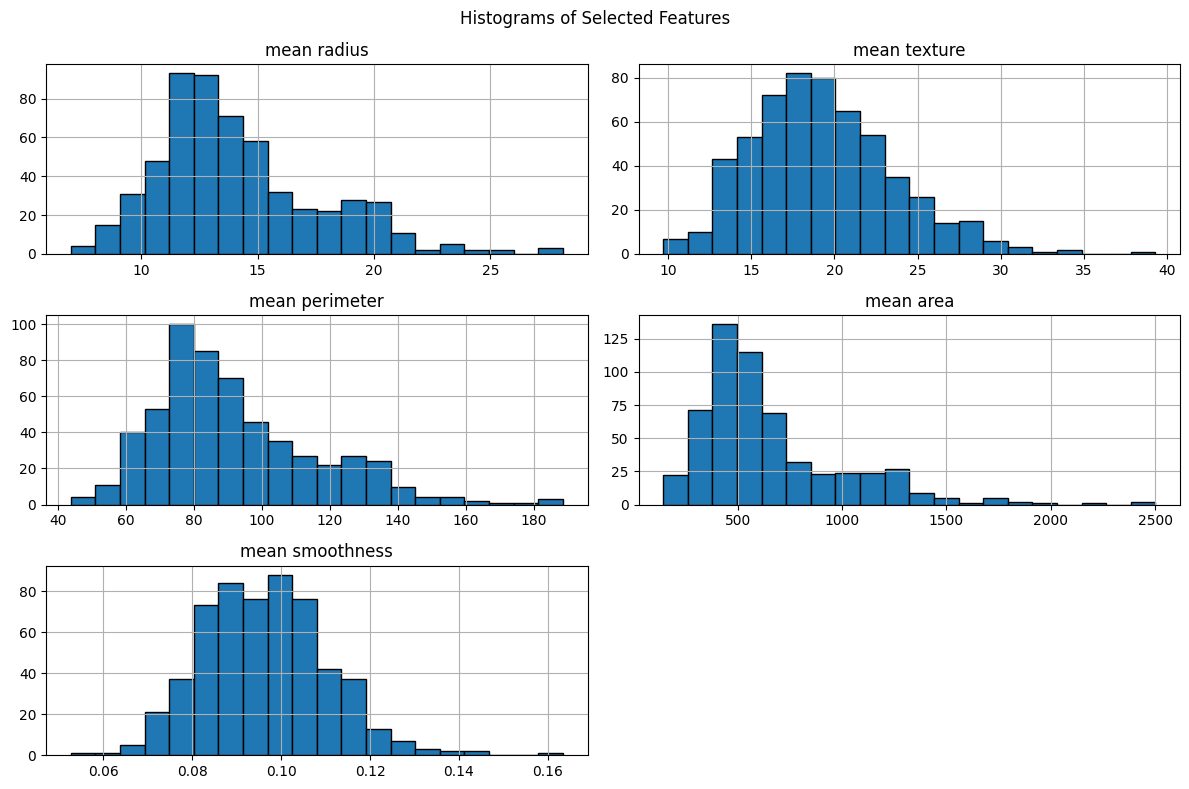

In [9]:
# 6. Histograms for selected features
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Histograms of Selected Features")
plt.tight_layout()
plt.show()

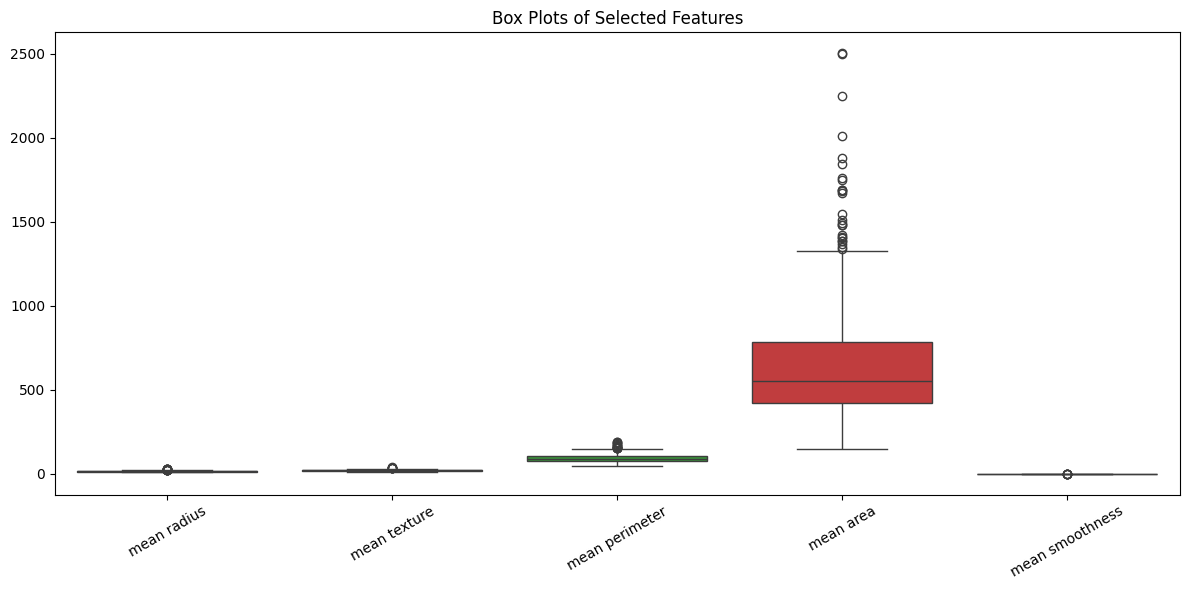

In [10]:
# 7. Box plots for selected features
plt.figure(figsize=(12, 6))

sns.boxplot(data=X[selected_features])

plt.title("Box Plots of Selected Features")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

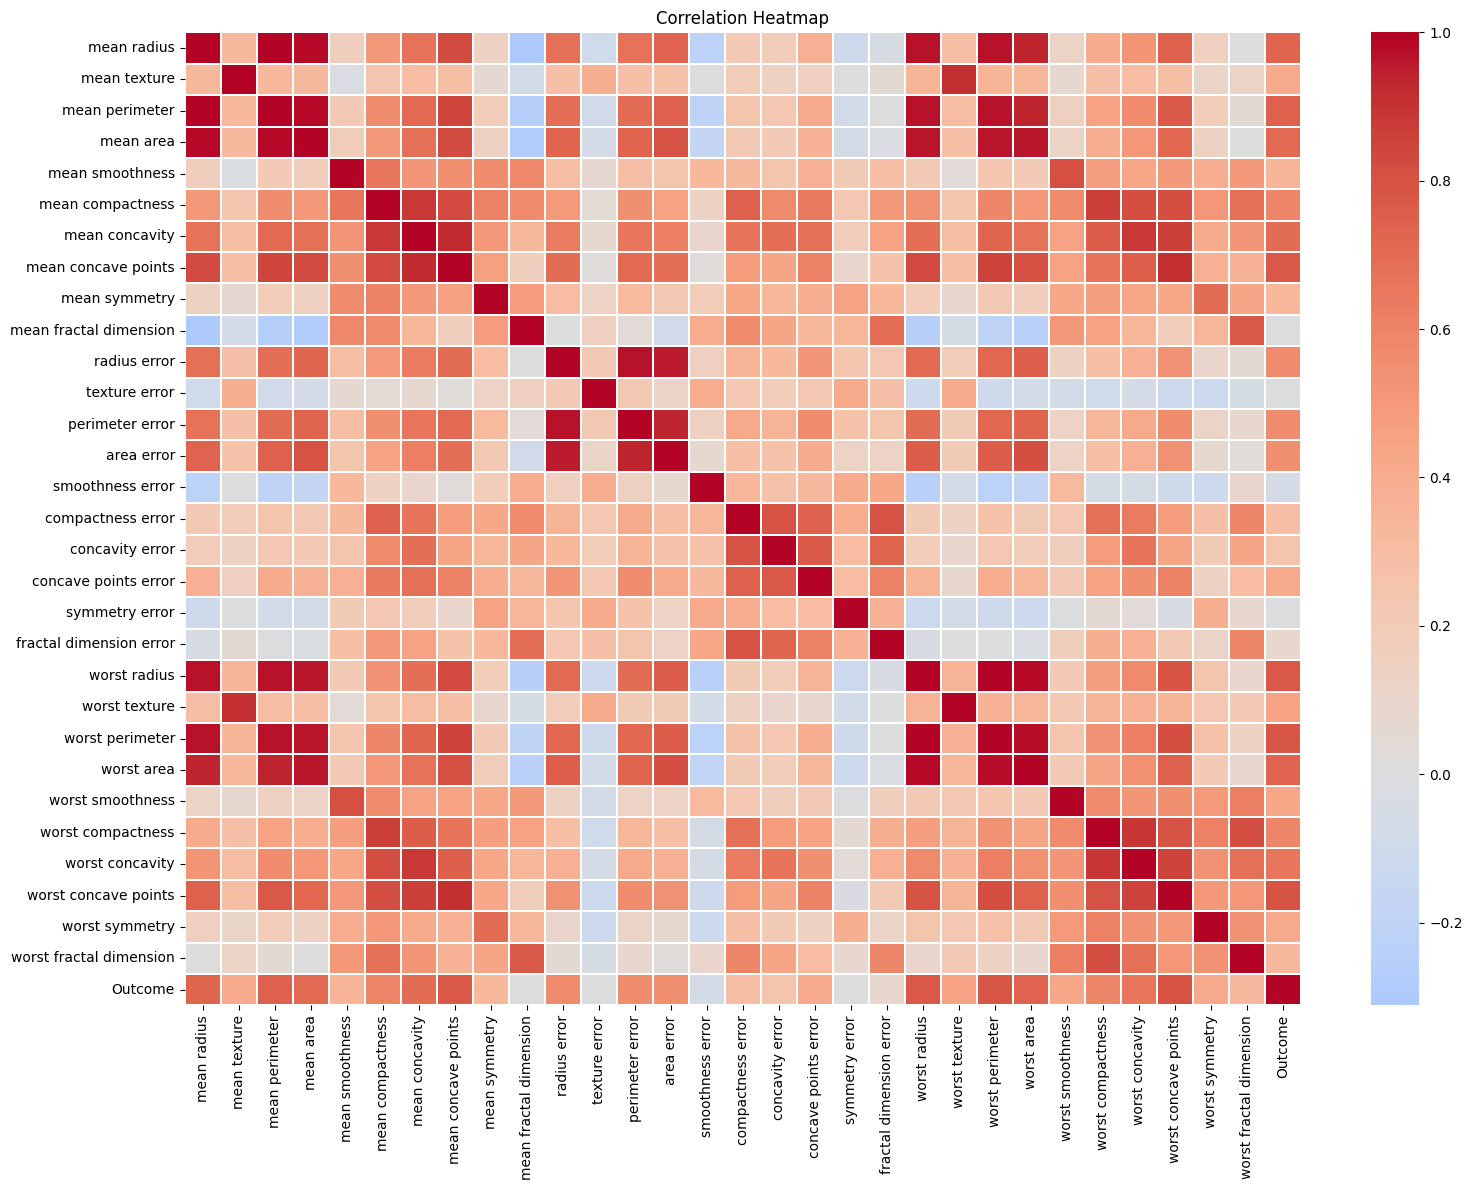

In [11]:
# 8. Correlation heatmap
plt.figure(figsize=(16, 12))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


CLASS DISTRIBUTION
Outcome
0    357
1    212
Name: count, dtype: int64

Class percentages:
Outcome
0    62.74
1    37.26
Name: count, dtype: float64


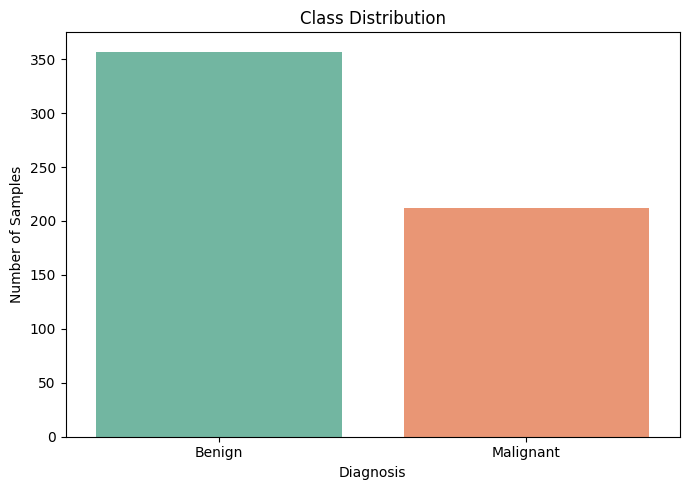

In [12]:

# 9. Class distribution
class_counts = y.value_counts().sort_index()

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print(class_counts)

print("\nClass percentages:")
print((class_counts / len(y) * 100).round(2))

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y,
    hue=y,
    palette="Set2",
    legend=False
)

plt.xticks([0, 1], ["Benign", "Malignant"])
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [14]:
# -------------------- TASK 2 -------------------------------
# DATA PREPROCESSING

# 1. Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


Training samples: 455
Testing samples: 114

Training class distribution:
Outcome
0    285
1    170
Name: count, dtype: int64

Testing class distribution:
Outcome
0    72
1    42
Name: count, dtype: int64


In [15]:
# 2. Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature standardization completed.")


Feature standardization completed.


In [16]:
# -------------------- TASK 3 -------------------------------
# MODEL TRAINING AND BASIC EVALUATION

# 1. Train Logistic Regression model

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [17]:
# 2. Predictions

y_pred = model.predict(X_test_scaled)

# Probability of malignant class (class 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [18]:
# 3. Evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred, pos_label=1, zero_division=0
)

recall = recall_score(
    y_test, y_pred, pos_label=1, zero_division=0
)

f1 = f1_score(
    y_test, y_pred, pos_label=1, zero_division=0
)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


MODEL EVALUATION
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1-score : 0.9512


In [19]:
# 4. Classification report for both classes

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114




Confusion Matrix:
[[71  1]
 [ 3 39]]


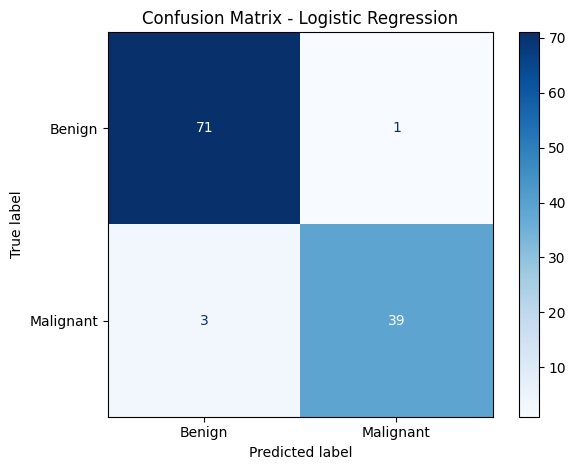

In [20]:
# 5. Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()


ROC-AUC Score: 0.9960


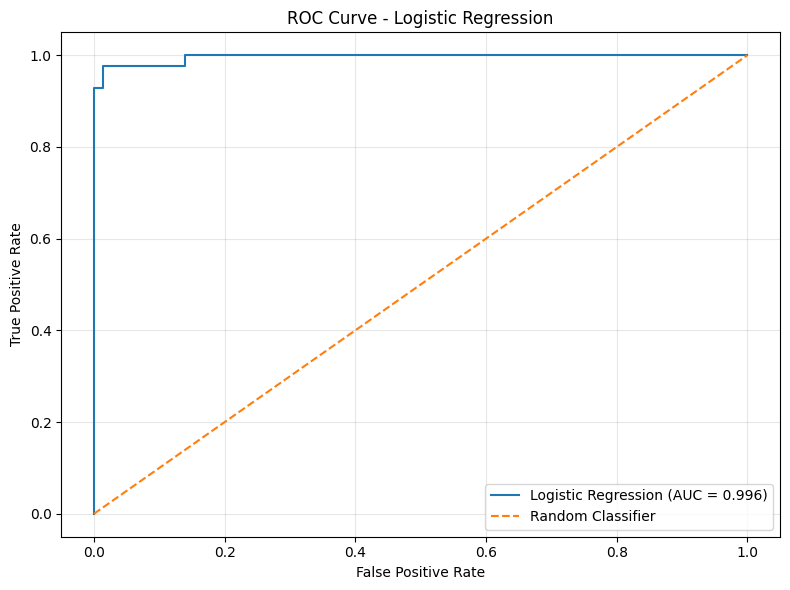

In [21]:
# 6. ROC curve and AUC score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob,
    pos_label=1
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"\nROC-AUC Score: {auc_score:.4f}")

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# -------------------- FINAL SUMMARY ------------------------

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"Dataset samples       : {len(df)}")
print(f"Number of features    : {X.shape[1]}")
print(f"Training samples      : {len(X_train)}")
print(f"Testing samples       : {len(X_test)}")
print(f"Accuracy              : {accuracy:.4f}")
print(f"Malignant precision   : {precision:.4f}")
print(f"Malignant recall      : {recall:.4f}")
print(f"Malignant F1-score    : {f1:.4f}")
print(f"ROC-AUC               : {auc_score:.4f}")

print("\nAssignment completed successfully.")


FINAL SUMMARY
Dataset samples       : 569
Number of features    : 30
Training samples      : 455
Testing samples       : 114
Accuracy              : 0.9649
Malignant precision   : 0.9750
Malignant recall      : 0.9286
Malignant F1-score    : 0.9512
ROC-AUC               : 0.9960

Assignment completed successfully.
